In [33]:
import glob
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import torch
import pickle
import umap
import matplotlib.pyplot as plt

from mmidas.cplMixVAE import cpl_mixVAE
from mmidas.eval import summarize_inference
from mmidas.utils.config_tools import get_paths
from mmidas.utils.data_tools import load_data, get_loaders, generate_colors
from mmidas.utils.batch_removal import align_query


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
toml_file = 'pyproject.toml'
device = 'cpu'
config = get_paths(toml_file=toml_file)
data_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['anndata_file']
gene_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['hvg_file']
results_path = config['paths']['main_dir'] / config['paths']['saving_path']
available_models = glob.glob(str(results_path) + '/*')

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...


In [3]:
# load retroseq data
retor_file = config['paths']['main_dir'] / config['paths']['data_path'] / 'retroSeq.h5ad'
retro_ad = sc.read_h5ad(retor_file)
gene_id = retro_ad.var.index.values

In [4]:
old_data = load_data(file=data_file, gene_file=gene_file) 
ref_genes = old_data['gene_id']
ref_data = old_data['log1p']
n_gene = len(ref_genes)

Number of cells: 4608, Number of genes: 1827


In [5]:
# find genes are not in the reference gene list
missing_gene = list(set(ref_genes) - set(gene_id))
print('Missing genes: ', missing_gene)

exclucive_gene_idx = [np.where(ref_genes == gene)[0][0] for gene in missing_gene]
gene_idx = np.delete(np.arange(n_gene), exclucive_gene_idx)

# find index of genes 
gene_index = [np.where(gene_id == gene)[0][0] for gene in ref_genes if sum(gene_id == gene) > 0]

Missing genes:  ['Gm35438 ENSMUSG00000118020', 'Gm11099', '4930517O19Rik']


In [6]:
retro_data = dict()
retro_data['log1p'] = np.zeros((retro_ad.X.shape[0], n_gene))
retro_data['log1p'][:, gene_idx] = np.log1p(retro_ad.X[:, gene_index].toarray())
retro_data['gene_id'] = ref_genes
retro_data['cell_id'] = retro_ad.obs_names
for key in retro_ad.obs.keys():
        retro_data[key] = retro_ad.obs[key].values
        
print(retro_data['log1p'].shape)

(525, 1827)


In [7]:
# convert data to torch
ref_data = torch.tensor(ref_data, dtype=torch.float32)
query_data = torch.tensor(retro_data['log1p'], dtype=torch.float32)
# Remove batch effect between AD and patchseq data
corrected_mtx = align_query(reference=ref_data, query=query_data, neighborhood_size=250, num_anchors=5, kernel_scale=1.0)

Determining neighborhood...
Computing correction...      
Completed.                           


In [8]:
# Evaluate the alignment between AD and patchseq data
corrected_data = corrected_mtx.detach().numpy()
dataset_1 = np.concatenate((ref_data, retro_data['log1p']), axis=0)
dataset_2 = np.concatenate((ref_data, corrected_data), axis=0)
embedding_1 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_1)
embedding_2 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_2)

/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


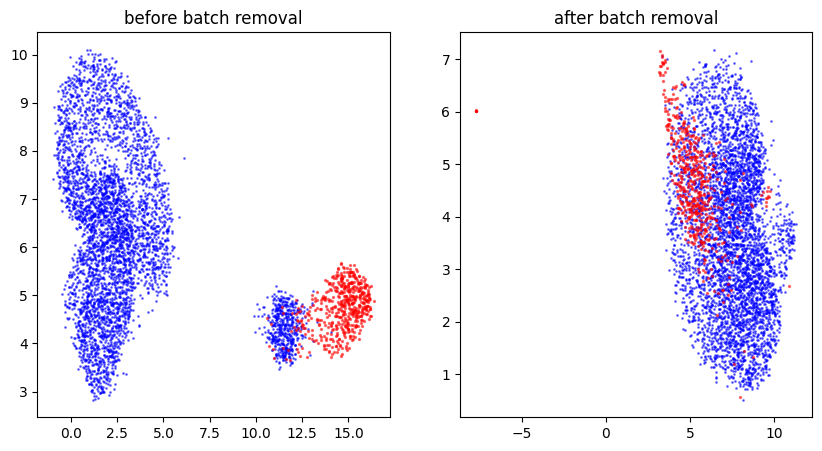

In [9]:
ref_samp_size = ref_data.shape[0]   
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(embedding_1[:ref_samp_size, 0], embedding_1[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[0].scatter(embedding_1[ref_samp_size:, 0], embedding_1[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[1].scatter(embedding_2[:ref_samp_size, 0], embedding_2[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[1].scatter(embedding_2[ref_samp_size:, 0], embedding_2[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[0].set_title('before batch removal')
ax[1].set_title('after batch removal')
plt.show()

In [12]:
retro_data_crt = dict()
retro_data_crt['log1p'] = corrected_data
for key in retro_data.keys():
    if key != 'log1p':
        retro_data_crt[key] = retro_data[key]

# save corrected data dictionary
with open(config['paths']['main_dir'] / config['paths']['data_path'] / 'corrected_retroSeq.pkl', "wb") as f:
    pickle.dump(retro_data_crt, f)

In [13]:
# Load from file
with open(config['paths']['main_dir'] / config['paths']['data_path'] / 'corrected_retroSeq.pkl', "rb") as f:
    retro_data_crt = pickle.load(f)

print(retro_data_crt['log1p'].shape)

(525, 1827)


In [14]:
selected_model_file = available_models[0]
trained_models = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_*')
# Get the model parameters from the selected model
param_vairables = selected_model_file.split('/')[-1].split('_')
params = {}
for p in range(0, len(param_vairables), 2):
    try:
        params[param_vairables[p]] = float(param_vairables[p+1])
        if params[param_vairables[p]] == int(params[param_vairables[p]]):
            params[param_vairables[p]] = int(params[param_vairables[p]])
    except ValueError:
        params[param_vairables[p]] = param_vairables[p+1]

In [15]:
print('Initializing mixvae model ...')
mixvae = cpl_mixVAE(saving_folder=selected_model_file, device=device)
mixvae.init_model(
                n_categories=params['Cdim'],
                state_dim=params['Sdim'],
                input_dim=n_gene,
                fc_dim=params['fcdim'],
                lowD_dim=params['Zdim'],
                n_arm=params['narm'],
                tau=params['tau'],
                )

Initializing mixvae model ...
---> Using CPU!


In [16]:
ref_data_loader, _, _, _, _, _ = get_loaders(x=ref_data, batch_size=100)
retro_data_loader, _, _, _, _, _ = get_loaders(x=corrected_data, batch_size=100)

In [17]:
model_order = 6
selected_model = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_after_pruning_' + str(mixvae.n_categories - model_order) + '*')[0]
mixvae.variational = False
ref_outcome= summarize_inference(mixvae, selected_model, ref_data_loader)
retro_outcome = summarize_inference(mixvae, selected_model, retro_data_loader)

Model /cpl_mixVAE_model_after_pruning_9_2025-01-04-14-57-40.pth
Model /cpl_mixVAE_model_after_pruning_9_2025-01-04-14-57-40.pth


In [18]:
print(f'Consensus between arms: ', np.sum(ref_outcome['pred_label'][-1][0] == ref_outcome['pred_label'][-1][1]) / len(ref_outcome['pred_label'][-1][0]))
print(f'Consensus between corrected and reference data: ', np.sum(retro_outcome['pred_label'][-1][0] == retro_outcome['pred_label'][-1][1]) / len(retro_outcome['pred_label'][-1][0]))
print(f"Identified cell types: {np.unique(retro_outcome['pred_label'][-1][0])}")

Consensus between arms:  0.9969618055555556
Consensus between corrected and reference data:  0.9714285714285714
Identified cell types: [ 2. 14.]


In [19]:
_, data_index = retro_data_loader.dataset.tensors
data_index = data_index.numpy().astype(int)
predicted_label = retro_outcome['pred_label'][0][0]
unique_labels = np.unique(predicted_label)
colors = generate_colors(len(unique_labels))
retro_cell_colors = np.zeros(retro_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each cell
for ic, c in enumerate(unique_labels):
    retro_cell_colors[predicted_label == c] = colors[ic]

sex = np.unique(retro_data['gender'])
colors = generate_colors(len(sex))
retro_sex_colors = np.zeros(retro_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each sex
for ic, c in enumerate(sex):
    retro_sex_colors[retro_data['gender'] == c] = colors[ic]

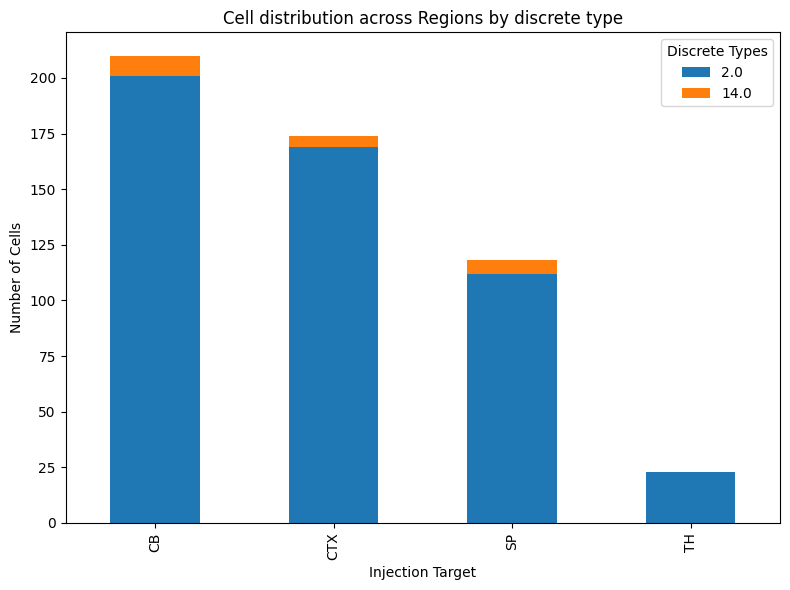

In [20]:
# Plotting the stacked bar plot
fig, ax = plt.subplots(figsize=(8, 6))
df_ = pd.crosstab(retro_data['injection_target'], predicted_label)

# Create the stacked bar plot
df_.plot(kind='bar', stacked=True, ax=ax)

# Adding labels and title
ax.set_ylabel('Number of Cells')
ax.set_xlabel('Injection Target')
ax.set_title('Cell distribution across Regions by discrete type')
ax.legend(title='Discrete Types')

plt.tight_layout()
plt.show()

In [49]:
# mix to data dictionary
mutual_keys = old_data.keys() & retro_data_crt.keys()
len_ref_data = old_data['log1p'].shape[0]
len_retro_data = retro_data_crt['log1p'].shape[0]
# concatenate dictiornaies with common keys
mix_data = {key: np.concatenate((old_data[key], retro_data_crt[key]), axis=0) for key in mutual_keys}
mix_data['sample_id'] = np.concatenate((old_data['sample_id'], retro_data_crt['sample_name']), axis=0)
mix_data['external_donor_name'] = np.concatenate((old_data['external_donor_name'], retro_data_crt['exp_component_name']), axis=0)
mix_data['sex'] = np.concatenate((old_data['sex'], retro_data_crt['gender']), axis=0)
mix_data['age'] = np.concatenate((np.array([' '] * len_ref_data), retro_data_crt['age']), axis=0)
mix_data['batch'] = np.concatenate((old_data['batch'], np.array([' '] * len_retro_data)), axis=0)
mix_data['injection_target'] = np.concatenate((np.array([' '] * len_ref_data), retro_data_crt['injection_target']), axis=0)
mix_data['dataset'] = np.concatenate((np.array(['ref'] * len_ref_data), np.array(['retroseq'] * len_retro_data)), axis=0)

In [50]:
mix_data_loader, _, _, _, _, _ = get_loaders(x=mix_data['log1p'], batch_size=100)
mix_outcome= summarize_inference(mixvae, selected_model, mix_data_loader)

Model /cpl_mixVAE_model_after_pruning_9_2025-01-04-14-57-40.pth


In [51]:
_, data_index = mix_data_loader.dataset.tensors
data_index = data_index.numpy().astype(int)
predicted_label = mix_outcome['pred_label'][0][0]
unique_labels = np.unique(predicted_label)
colors = generate_colors(len(unique_labels))
cell_colors = np.zeros(mix_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each cell
for ic, c in enumerate(unique_labels):
    cell_colors[predicted_label == c] = colors[ic]

batch = np.unique(mix_data['batch'])
colors = generate_colors(len(batch))
batch_colors = np.zeros(mix_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each batch
for ic, c in enumerate(batch):
    batch_colors[mix_data['batch'] == c] = colors[ic]

external_donor_name = np.unique(mix_data['external_donor_name'])
colors = generate_colors(len(external_donor_name))
donor_colors = np.zeros(mix_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each donor
for ic, c in enumerate(external_donor_name):
    donor_colors[mix_data['external_donor_name'] == c] = colors[ic]

sex = np.unique(mix_data['sex'])
colors = generate_colors(len(sex))
sex_colors = np.zeros(mix_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each sex
for ic, c in enumerate(sex):
    sex_colors[mix_data['sex'] == c] = colors[ic]

roi = np.unique(mix_data['injection_target'])
colors = generate_colors(len(roi))
roi_colors = np.zeros(mix_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each roi
for ic, c in enumerate(roi):
    roi_colors[mix_data['injection_target'] == c] = colors[ic]
    
data_id = np.unique(mix_data['dataset'])
colors = generate_colors(len(data_id))
dataset_colors = np.zeros(mix_data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each roi
for ic, c in enumerate(data_id):
    dataset_colors[mix_data['dataset'] == c] = colors[ic]

0


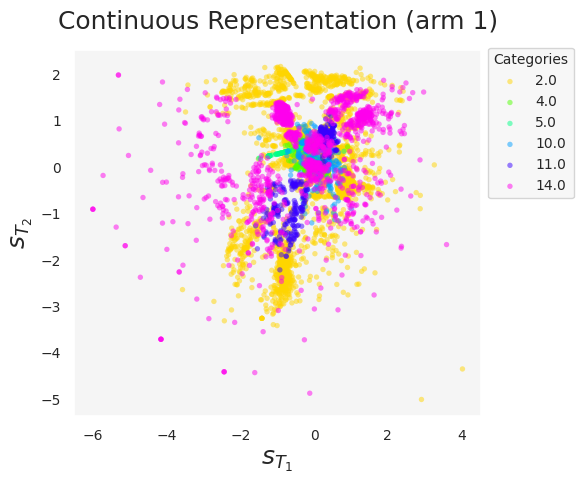

In [63]:
clr_var = cell_colors
label = predicted_label

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(1):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim == 2:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0], mix_outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    elif mixvae.state_dim == 3:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0],
                        mix_outcome['state_mu'][arm][indices, 1],
                        mix_outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title='Categories', title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


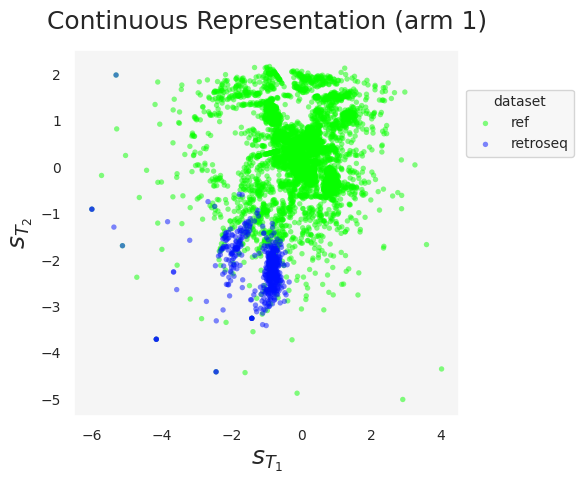

In [62]:
factor = 'dataset'
clr_var = dataset_colors[data_index]
label = mix_data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(1):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim == 2:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0], mix_outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    elif mixvae.state_dim == 3:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0],
                        mix_outcome['state_mu'][arm][indices, 1],
                        mix_outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


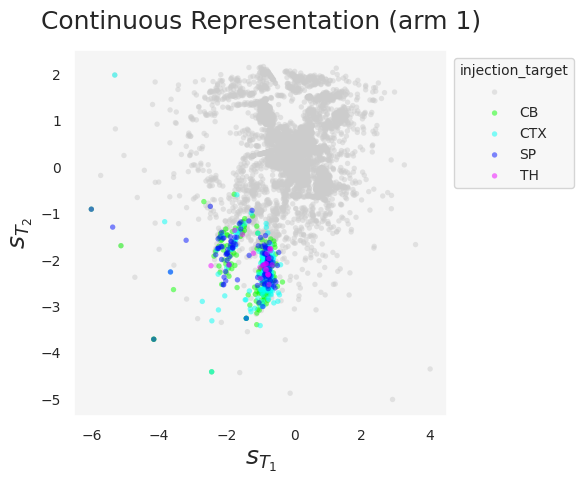

In [61]:
factor = 'injection_target'
clr_var = roi_colors[data_index]
clr_var[clr_var=='#fcf500'] = '#cccccc'
label = mix_data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(1):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim == 2:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0], mix_outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    elif mixvae.state_dim == 3:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0],
                        mix_outcome['state_mu'][arm][indices, 1],
                        mix_outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


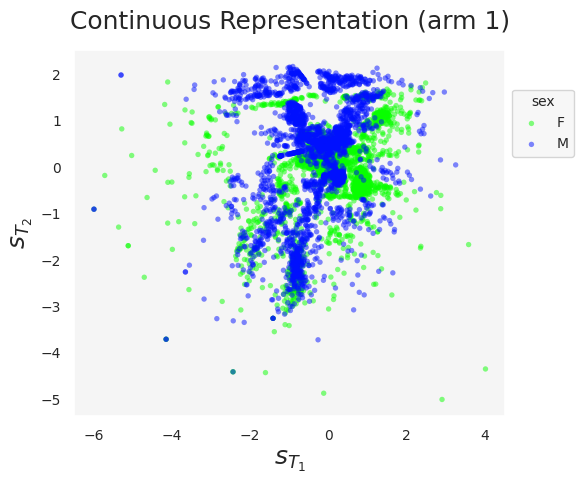

In [64]:
factor = 'sex'
clr_var = sex_colors[data_index]
label = mix_data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(1):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim == 2:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0], mix_outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    elif mixvae.state_dim == 3:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(mix_outcome['state_mu'][arm][indices, 0],
                        mix_outcome['state_mu'][arm][indices, 1],
                        mix_outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()